## SAGOS

# INISIALISASI LIBRARY YANG AKAN DIGUNAKAN

In [5]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt 

baris kode ini saya gunakan untuk mengimport library yang sekiranya akan digunakan dibawah nantinya

# PERSIAPAN BAHAN DAN PENAMPILAN CITRA

In [6]:
citra1 = cv.imread(r"Assets\citra1.PNG")
citra2 = cv.imread(r"Assets\citra2.PNG")

print(citra1.shape)
print(citra2.shape)

(780, 780, 3)
(780, 780, 3)


baris kode diatas untuk membaca 2 file gambar dari folder Assets dengan fungsi `cv.imread()` lalu menyimpannya pada variabel citra1 dan citra2. Hasil dari fungsi imread() adalah array tiga dimensi(dapat dilihat pada hasil print(citra.shape) yang menghasilkan angka 3 pada angka terakhir) yang merepresentasikan nilai piksel dalam format warna BGR (Blue, Green, Red) dengan nilai antara 0 hingga 255 untuk setiap channel warnanya.

Text(0.5, 1.0, 'Citra 2')

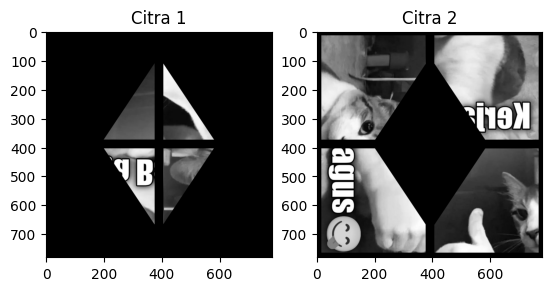

In [7]:
plt.subplot(1, 2, 1)
plt.imshow(citra1)
plt.title('Citra 1')

plt.subplot(1, 2, 2)
plt.imshow(citra2)
plt.title('Citra 2')

fungsi `plt.subplot(1, 2, n)` pada kode diatas akan membagi canvas menjadi 1 baris dan 2 kolom. sedangkan fungsi `plt.imshow(citra_n)` akan menampilkan gambar dan fungsi `plt.title('name')` akan menampilkan teks di atas gambar yang ditampilkan

In [8]:
citra1 = cv.cvtColor(citra1, cv.COLOR_BGR2GRAY)
citra2 = cv.cvtColor(citra2, cv.COLOR_BGR2GRAY)

print(citra1.shape)
print(citra2.shape)

(780, 780)
(780, 780)


Baris kode ini digunakan untuk mengubah gambar dari format warna BGR menjadi format grayscale menggunakan fungsi `cv.cvtColor()` dengan parameter `cv.COLOR_BGR2GRAY`. Proses konversi ini mengubah gambar yang semula memiliki 3 channel warna menjadi hanya 1 channel(dapat dilihat pada hasil `print(citra_n.shape)` dimana angka yang ditampilkan hanya merupakan angka tinggi dan lebar dari citra tersebut(780, 780)), di mana setiap piksel direpresentasikan dengan satu nilai antara 0 (hitam) hingga 255 (putih).

Text(0.5, 1.0, 'Citra 2')

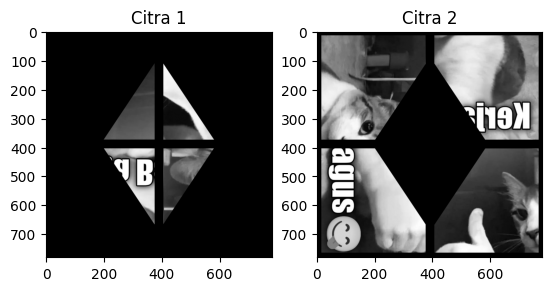

In [9]:
plt.subplot(1, 2, 1)
plt.imshow(citra1, cmap='gray')
plt.title('Citra 1')

plt.subplot(1, 2, 2)
plt.imshow(citra2, cmap='gray')
plt.title('Citra 2')

Baris kode ini menampilkan gambar hasil konversi grayscale dalam satu kanvas menggunakan layout 1 baris dan 2 kolom. Parameter `cmap="gray"` pada fungsi `plt.imshow()` digunakan agar gambar grayscale ditampilkan dalam warna hitam putih yang sesuai. Tanpa parameter ini, matplotlib akan menampilkan gambar grayscale dengan peta warna default yang menghasilkan tampilan warna-warni yang tidak sesuai.

## ROTASI

In [10]:
def rotate(image, val): 
    h, w = image.shape 
    val = int(val) % 360  
    if val == 0: return image 
    elif val == 90: 
        rot = np.zeros((w, h), dtype=image.dtype) 
        for i in range(h): 
            for j in range(w): rot[j, h - 1 - i] = image[i, j] 
        return rot 
    elif val == 180: 
        rot = np.zeros_like(image, dtype=image.dtype) 
        for i in range(h): 
            for j in range(w): rot[h - 1 - i, w - 1 - j] = image[i, j] 
        return rot 
    elif val == 270:  
        rot = np.zeros((w, h), dtype=image.dtype) 
        for i in range(h): 
            for j in range(w): rot[w - 1 - j, i] = image[i, j] 
        return rot 
    return image 

baris kode diatas akan mendifinisikan fungsi rotate(image) dimana fungsi ini akan memutar citra sebesar n(parameter val) derajat searah jarum jam dengan memanipulasi posisi piksel menggunakan indeks matriks.

`h, w = image.shape` digunakan untuk mendapatkan tinggi dan lebar citra.
`np.zeros((w, h))` digunakan untuk membuat matriks baru dengan ukuran terbalik, karena hasil rotasi akan menukar dimensi tinggi dan lebar.
Perulangan `for` digunakan untuk mengakses setiap piksel pada citra asli.
`rot[j, h - 1 - i] = image[i, j]` merupakan inti rotasi, di mana:
  - koordinat `(i, j)` pada citra asli dipindahkan ke posisi baru `(j, h-1-i)`
  - operasi `h - 1 - i` digunakan untuk membalik arah baris sehingga menghasilkan rotasi 90° searah jarum jam

Rotasi manual ini penting untuk memahami bagaimana transformasi geometri bekerja pada level piksel tanpa bantuan fungsi otomatis.

Text(0.5, 1.0, 'Citra 1')

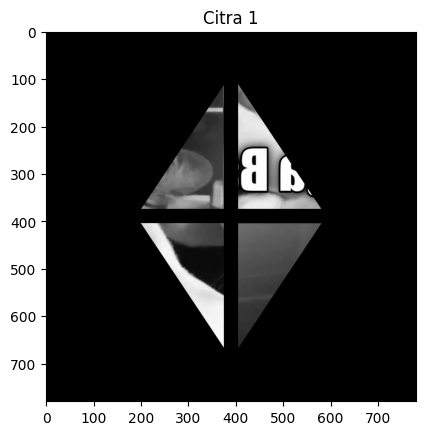

In [11]:
citra1 = rotate(citra1, 180)

plt.imshow(citra1, cmap='gray')
plt.title('Citra 1')

baris kode diatas akan menampilkan citra1 hasil rotasi sebesar 180 derajat searah jarum jam dengan menggunakan fungsi `rotate()`

# MERGE

In [12]:
def merge(img1, img2): 
    return img1 + img2 

baris kode diatas akan mendefinisikan fungsi `merge(img1, img2)` yang mana fungsi ini akan menggabungkan 2 buah gambar yang menjadi parameter dari fungsi tersebut menjadi 1 kesatuan gambar yang utuh dengan menjumlahkan semua pixel dari kedua gambar sesuai posisi pixel yang ada pada kedua gambar tersebut

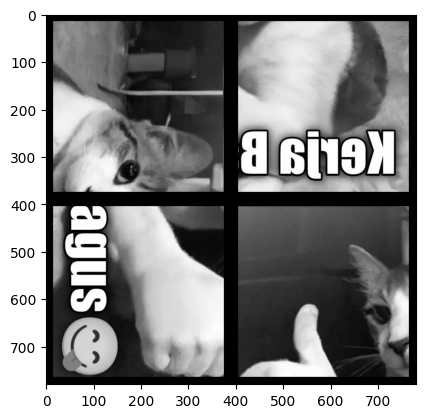

In [13]:
citra = merge(citra1, citra2)

plt.imshow(citra, cmap='gray')

baris kode diatas akan menampilkan satu buah gambar utuh yang merupakan hasil gabungan dari duah buah citra yaitu citra1 dan citra2 dengan menggunakan fungsi `merge()` yang sudah dibuat sebelumnya

# PEMOTONGAN CITRA

In [14]:
print(citra .shape)

(780, 780)


baris kode diatas akan menampilkan tinggi dan lebar dari citra kita saat ini, informasi ini akan digunakan untuk memotong citra agar mendapatkan hasil yang sama rata

In [15]:
def slice(img, a, b, mode='H'): 
    return img[a:b, :] if mode == 'H' else img[:, a:b]

baris kode diatas mendefinisikan fungsi slice(), fungsi ini bekerja dengan cara mengambil ukuran dari piksel awal(parameter a) sampai piksel akhir(parameter b). img[a:b, :] berarti akan mengambil piksel atas sampai piksel bawah (tergantung value dari a dan b) lalu mengambil keseluruhan pixel secara horizontal(seolah olah memotong gambar dari atas ke bawah), kode ini akan diambil jika mode bernilai 'H', selain itu maka akan mengambil keseluruhan pixel secara vertikal dan mengambil pixel dari a sampai b secara horizontal(jadi seolah olah memotong dari atas ke bawah)

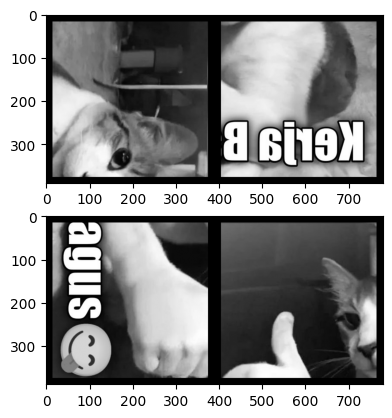

In [16]:
citraAtas = slice(citra, 0, 389, 'H')
citraBawah = slice(citra, 390, 779, 'H')

plt.subplot(2, 1, 1)
plt.imshow(citraAtas, cmap='gray')
plt.subplot(2, 1, 2)
plt.imshow(citraBawah, cmap='gray')

Kode diatas akan memotong citra menjadi 2 bagian dengan menggunakan fungsi slice(). Menggunakan informasi dari print(citra.shape) sebelumnya agar mendapatkan citra dengan ukuran sama rata, maka kita hanya perlu membagi 780/2 = 390, ini berarti kita akan mengambil 0-389 dan 390-779, citra hasil pemotongan ini akan disimpan pada variabel citraAtas dan citraBawah.

Text(0.5, 1.0, 'Citra 4')

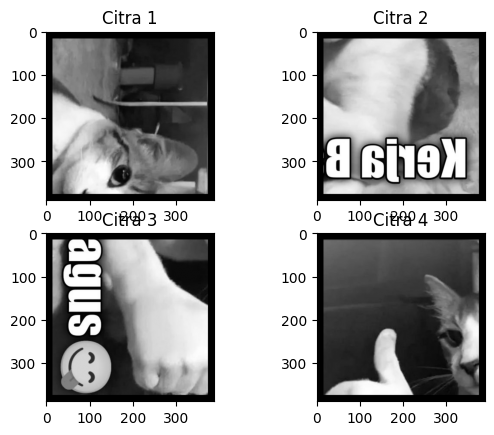

In [17]:
citra1 = slice(citraAtas, 0, 389, 'C')
citra2 = slice(citraAtas, 390, 779, 'C')
citra3 = slice(citraBawah, 0, 389, 'C')
citra4 = slice(citraBawah, 390, 779, 'C')

plt.subplot(2, 2, 1)
plt.imshow(citra1, cmap='gray')
plt.title('Citra 1')
plt.subplot(2, 2, 2)
plt.imshow(citra2, cmap='gray')
plt.title('Citra 2')
plt.subplot(2, 2, 3)
plt.imshow(citra3, cmap='gray')
plt.title('Citra 3')
plt.subplot(2, 2, 4)
plt.imshow(citra4, cmap='gray')
plt.title('Citra 4')

kode diatas akan memotong citraAtas dan citraBawah secara vertical(dengan parameter mode = 'C' atau selain 'H')dengan menggunakan fungsi `slice()` lalu kemmudian menyimpan hasil pemotongan tersebut kedalam citra1, citra2, citra3 dan citra4

# FLIPPING

In [18]:
def flipping(image, mode='x'):
    h, w = image.shape
    hasil = np.zeros((h, w), dtype = image.dtype)
    for i in range (h):
        for j in range (w):
            if mode == 'x':
                hasil[i, j] = image[h-1-i, j]
            elif mode == 'y':
                hasil[i, j] = image[i, w-1-j]
    return hasil

Baris kode ini mendefinisikan fungsi `flipping()` yang digunakan untuk mencerminkan gambar secara horizontal maupun vertikal. Fungsi ini menerima dua parameter yaitu image sebagai gambar masukan dan mode sebagai arah pencerminan. Jika mode bernilai 'x', gambar akan dicerminkan secara vertikal dengan menukar posisi baris, baris pertama menjadi baris terakhir dan sebaliknya  menggunakan rumus `hasil[i,j] = image[h-1-i, j]`. Jika mode bernilai 'y', gambar akan dicerminkan secara horizontal dengan menukar posisi kolom menggunakan rumus `hasil[i,j] = image[i, w-1-j]`. Proses ini dilakukan dengan dua buah loop yang mengunjungi setiap piksel gambar satu per satu.

Text(0.5, 1.0, 'Citra 4')

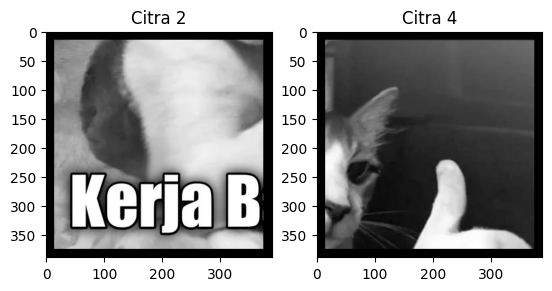

In [19]:
citra2 = flipping(citra2, 'y')
citra4 = flipping(citra4, 'y')

plt.subplot(1, 2, 1)
plt.imshow(citra2, cmap='gray')
plt.title('Citra 2')
plt.subplot(1, 2, 2)
plt.imshow(citra4, cmap='gray')
plt.title('Citra 4')

kode diatas melakukan flippiing  kepada citra2 dan citra4 lalu kemudia menampilkannya pada canvas ukuran 1 baris 2 kolom

Text(0.5, 1.0, 'Citra 3')

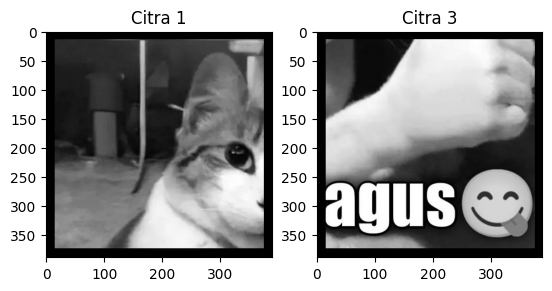

In [20]:
citra1 = rotate(citra1, 270)
citra3 = rotate(citra3, 270)

plt.subplot(1, 2, 1)
plt.imshow(citra1, cmap='gray')
plt.title('Citra 1')
plt.subplot(1, 2, 2)
plt.imshow(citra3, cmap='gray')
plt.title('Citra 3')

kode diatas melakukan rotate kepada citra1 dan citra3 lalu kemudian menampilkannya melalui canvas berukuran 1 baris 2 kolom

# TRANSLASI

In [21]:
def translasi(image, geser_kolom_x=0, geser_baris_y=0): 
    image = np.array(image) 
    h, w = image.shape 
    hasil = np.zeros((h, w), dtype=image.dtype) 
    for i in range(h): 
        for j in range(w): 
            new_i = i + geser_baris_y 
            new_j = j + geser_kolom_x 
            if 0 <= new_i < h and 0 <= new_j < w: 
                hasil[new_i, new_j] = image[i, j] 
    return hasil 

kode diatas akan mendefinisikan fungsi `translasi()` yang digunakan untuk menggeser posisi piksel berdasarkan nilai koordinat arah pergeseran kolom dan baris yang ditentukan melalui parameter di fungsi tersebut. Setiap piksel pada koordinat `(i, j)` dipindahkan ke koordinat baru `(i + geser_baris_y, j + geser_kolom_x)`. Dilakukan pengecekan kondisi agar piksel yang baru tetap berada dalam rentang dimensi citra (`0` hingga `height/width`) untuk menghindari error indeks.

(np.float64(-0.5), np.float64(388.5), np.float64(388.5), np.float64(-0.5))

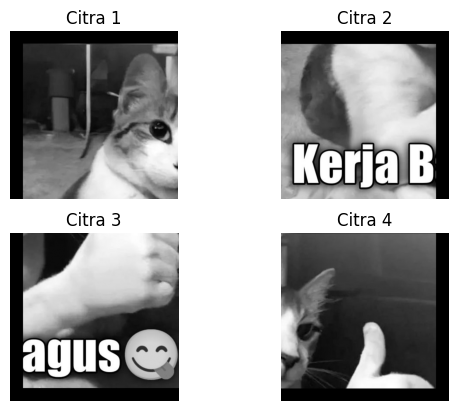

In [22]:
citra1 = translasi(citra1, 15, 15)
citra2 = translasi(citra2, -15, 15)
citra3 = translasi(citra3, 15, -15)
citra4 = translasi(citra4, -15, -15)

plt.subplot(2, 2, 1)
plt.imshow(citra1, cmap='gray')
plt.title('Citra 1')
plt.axis('off')
plt.subplot(2, 2, 2)
plt.imshow(citra2, cmap='gray')
plt.title('Citra 2')
plt.axis('off')
plt.subplot(2, 2, 3)
plt.imshow(citra3, cmap='gray')
plt.title('Citra 3')
plt.axis('off')
plt.subplot(2, 2, 4)
plt.imshow(citra4, cmap='gray')
plt.title('Citra 4')
plt.axis('off')

* **Implementasi Pergeseran**:
    * **Citra 1**: Digeser sejauh 15 piksel ke kanan dan 15 piksel ke bawah.
    * **Citra 2**: Digeser sejauh 15 piksel ke kiri dan 15 piksel ke bawah.
    * **Citra 3**: Digeser sejauh 15 piksel ke kanan dan 15 piksel ke atas.
    * **Citra 4**: Digeser sejauh 15 piksel ke kiri dan 15 piksel ke atas.
* baris `plt.axis('off')` berfungsi untuk menonaktifkan tampilan sumbu kordinat pada gambar

# DILATASI

In [23]:
def dilatasi(image, p1=0, p2=0, p3=0, p4=0): 
    h, w = image.shape 
    # skala 2x lipat 
    dilated = np.zeros((h * 2, w * 2)).astype(int) 
    for y in range(h * 2): 
        for x in range(w * 2): 
            dilated[y][x] = image[int(y / 2)][int(x / 2)] 
    # normalisasi (crop) sisi luar 
    sy, ey = max(0, p1), min(h * 2, h * 2 - p2) 
    sx, ex = max(0, p3), min(w * 2, w * 2 - p4) 
    return dilated[sy:ey, sx:ex]

kode diatas akan mendefinisikan fungsi dilatasi() yang akan melakukan perbesaran ukuran citra (scaling) sebesar dua kali lipat menggunakan teknik nearest neighbor interpolation. cara kerjanya ialah menduplikasi setiap satu piksel asli menjadi blok piksel 2x2 pada matriks baru yang berukuran dua kali lipat lebih besar. Setelah diperbesar, fungsi ini menggunakan parameter p1 hingga p4 untuk melakukan pemotongan (cropping) pada sisi-sisi luar citra, sehingga pengguna dapat menyesuaikan dimensi akhir citra setelah diperbesar.

Text(0.5, 1.0, 'Citra 4')

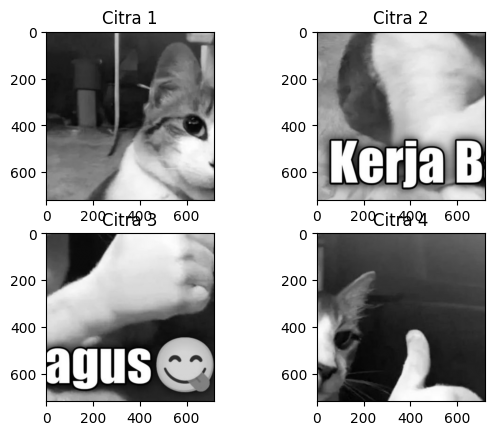

In [24]:
citra1 = dilatasi(citra1, 60, 0, 60, 0)
citra2 = dilatasi(citra2, 60, 0, 0, 60)
citra3 = dilatasi(citra3, 0, 60, 60, 0)
citra4 = dilatasi(citra4, 0, 60, 0, 60)

plt.subplot(2, 2, 1)
plt.imshow(citra1, cmap='gray')
plt.title('Citra 1')
plt.subplot(2, 2, 2)
plt.imshow(citra2, cmap='gray')
plt.title('Citra 2')
plt.subplot(2, 2, 3)
plt.imshow(citra3, cmap='gray')
plt.title('Citra 3')
plt.subplot(2, 2, 4)
plt.imshow(citra4, cmap='gray')
plt.title('Citra 4')

Potongan kode tersebut melakukan pembesaran (dilatasi) pada empat citra dan memotongnya di sudut yang berbeda-beda untuk ditampilkan dalam satu canvas berukuran 2 baris dan 2 kolom.
* penggunaannya:
    * Citra 1: Dipotong bagian atas dan kiri sebesar 60 piksel, sehingga fokus pada area kanan bawah.
    * Citra 2: Dipotong bagian atas dan kanan sebesar 60 piksel, sehingga fokus pada area kiri bawah.
    * Citra 3: Dipotong bagian bawah dan kiri sebesar 60 piksel, sehingga fokus pada area kanan atas.
    * Citra 4: Dipotong bagian bawah dan kanan sebesar 60 piksel, sehingga fokus pada area kiri atas.

# MERGE

In [25]:
def merge_horizontal(citra_1, citra_2): 
    c1, c2 = np.array(citra_1), np.array(citra_2) 
    tinggi = max(c1.shape[0], c2.shape[0]) 
    lebar = c1.shape[1] + c2.shape[1] 
    hasil = np.zeros((tinggi, lebar), dtype=c1.dtype) 
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1 
    hasil[0:c2.shape[0], c1.shape[1]:] = c2 
    return hasil 

def merge_vertikal(citra_1, citra_2): 
    c1, c2 = np.array(citra_1), np.array(citra_2) 
    tinggi = c1.shape[0] + c2.shape[0] 
    lebar = max(c1.shape[1], c2.shape[1]) 
    hasil = np.zeros((tinggi, lebar), dtype=c1.dtype) 
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1 
    hasil[c1.shape[0]:, 0:c2.shape[1]] = c2 
    return hasil 

* merge_horizontal: Fungsi ini menggabungkan dua citra secara berdampingan (kiri-kanan) dengan membuat kanvas baru yang lebarnya adalah total lebar kedua citra dan tingginya mengikuti citra yang paling tinggi.
* merge_vertikal: Fungsi ini menyusun dua citra secara bertumpuk (atas-bawah) dengan membuat kanvas baru yang tingginya adalah total tinggi kedua citra dan lebarnya mengikuti citra yang paling lebar.

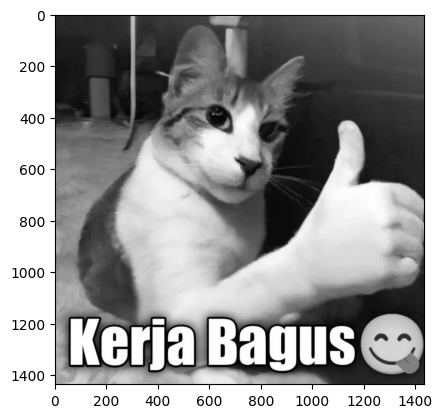

In [26]:
citra1 = merge_horizontal(citra1, citra4)
citra2 = merge_horizontal(citra2, citra3)

citra = merge_vertikal(citra1, citra2)

plt.imshow(citra, cmap='gray')

Potongan kode diatas akan  melakukan penggabungan empat potongan citra yang sebelumnya telah diproses menjadi satu kesatuan gambar utuh melalui penggabungan horizontal dan vertikal:
* Penggabungan Horizontal: Baris pertama menggabungkan citra1 dan citra4 secara berdampingan, sementara baris kedua menggabungkan citra2 dan citra3.
* Penggabungan Vertikal: Fungsi merge_vertikal kemudian menumpuk kedua hasil penggabungan horizontal tersebut untuk membentuk satu citra final.

Hasil Akhir: Proses ini menyatukan potongan-potongan detail menjadi satu matriks besar yang kemudian ditampilkan sebagai gambar tunggal.

# NORMALISASI

In [27]:
def normalisasi(citra):
    min_val = int(citra[0,0])
    max_val = int(citra[0,0])
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            if citra[i,j] < min_val: min_val = int(citra[i,j])
            if citra[i,j] > max_val: max_val = int(citra[i,j])
    
    hasil = np.zeros(citra.shape, dtype=np.uint8)
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            hasil[i,j] = int((int(citra[i,j]) - min_val) / (max_val - min_val) * 255)
    return hasil

def hitung_histogram(citra):
    hist = np.zeros(256, dtype=int)
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            hist[citra[i, j]] += 1
    return hist

* normalisasi: Fungsi ini melakukan peregangan kontras (contrast stretching) dengan mencari nilai piksel terendah dan tertinggi secara manual melalui perulangan, lalu memetakan ulang seluruh piksel ke rentang 0-255 agar kualitas visual citra lebih tajam.
* hitung_histogram: Fungsi ini menghitung distribusi frekuensi kemunculan setiap nilai intensitas warna (0-255) dalam citra dengan cara menelusuri seluruh piksel dan menjumlahkannya ke dalam array penampung.

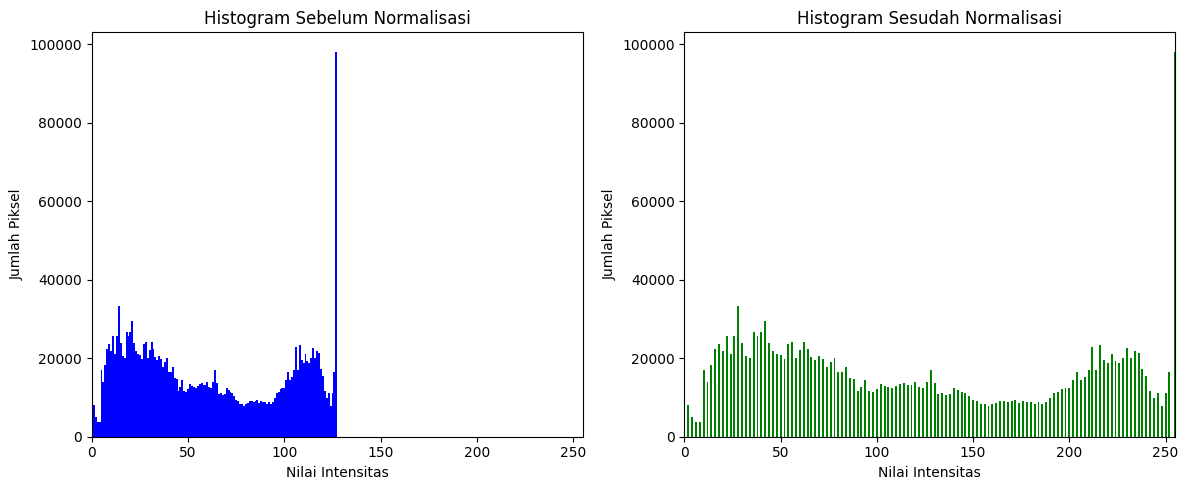

In [28]:
def normalize(image):
    imin, imax = image.min(), image.max()
    if imax == imin:
        return np.zeros_like(image, dtype=np.uint8) + 128
    norm = (image - imin) / (imax - imin) * 255
    return norm.astype(np.uint8)

# --- histogram sebelum 
hist_awal = hitung_histogram(citra // 2)

# --- normalisasi ---
normalized_image = normalize(citra // 2)
hist_normal = hitung_histogram(normalized_image)

# --- tampilkan berdampingan ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.bar(range(256), hist_awal, color='blue', width=1)
plt.title('Histogram Sebelum Normalisasi')
plt.xlabel('Nilai Intensitas')
plt.ylabel('Jumlah Piksel')
plt.xlim([0,255])

plt.subplot(1,2,2)
plt.bar(range(256), hist_normal, color='green', width=1)
plt.title('Histogram Sesudah Normalisasi')
plt.xlabel('Nilai Intensitas')
plt.ylabel('Jumlah Piksel')
plt.xlim([0,255])

plt.tight_layout()
plt.show()

Kode tersebut membandingkan distribusi intensitas piksel citra sebelum dan sesudah proses normalisasi dengan menampilkan histogramnya secara berdampingan. Citra input yang awalnya dipergelap melalui operasi citra // 2 mengakibatkan histogram awal menumpuk di area kiri (gelap), namun setelah diproses dengan fungsi normalize, nilai-nilai tersebut ditarik kembali menggunakan metode Min-Max Scaling agar memenuhi rentang penuh 0 hingga 255. Hasilnya, histogram sesudah normalisasi terlihat lebih tersebar merata ke seluruh spektrum, yang menandakan peningkatan kontras dan kejernihan detail pada citra tersebut.

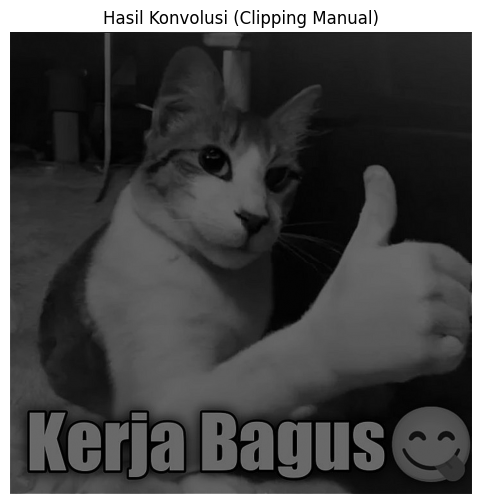

In [ ]:
kernel = np.array([
    [-0.1, -0.1, -0.1, -0.1],
    [-0.1,  0.4,  0.4, -0.1],
    [-0.1,  0.4,  0.4, -0.1],
    [-0.1, -0.1, -0.1, -0.1]
])

# 2. Fungsi Konvolusi Manual dengan Clipping Manual
def conv2d_manual(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape
    pad_h, pad_w = kh//2, kw//2
    
    # Tambahkan Zero Padding agar ukuran output sama dengan input
    padded = np.zeros((h + 2*pad_h, w + 2*pad_w))
    padded[pad_h:pad_h+h, pad_w:pad_w+w] = image
    
    # Siapkan matriks hasil dengan tipe data uint8
    result = np.zeros_like(image, dtype=np.uint8)
    
    for i in range(h):
        for j in range(w):
            # Ambil area gambar sesuai ukuran kernel
            region = padded[i:i+kh, j:j+kw]
            
            # Hitung nilai konvolusi (dot product sum)
            nilai = np.sum(region * kernel)
            
            # --- CLIPPING MANUAL ---
            # Memastikan nilai piksel tetap di rentang 0-255
            if nilai < 0:
                nilai = 0
            elif nilai > 255:
                nilai = 255
            
            # Simpan hasil sebagai integer
            result[i, j] = int(nilai)
            
    return result

# 3. Eksekusi dan Visualisasi
conv_clipped = conv2d_manual(normalized_image, kernel)

plt.figure(figsize=(6, 6))
plt.imshow(conv_clipped, cmap='gray')
plt.title('Hasil Konvolusi')
plt.axis('off')
plt.show()

Kode tersebut menerapkan proses konvolusi dua dimensi secara manual untuk mempertajam detail citra menggunakan kernel berukuran $4 \times 4$. Tahap pertama dimulai dengan penerapan zero padding, yaitu memberikan bingkai bernilai nol di sekeliling citra asli agar posisi kernel saat berada di tepian tidak keluar dari koordinat, sehingga ukuran citra hasil tetap konsisten dengan aslinya. Selanjutnya, program melakukan iterasi pada setiap piksel untuk menghitung nilai baru melalui perkalian elemen antara area lokal citra (region) dengan matriks kernel, yang kemudian dijumlahkan seluruhnya. Untuk menjaga integritas data citra 8-bit, diterapkan clipping manual yang secara tegas memaksa nilai di bawah 0 menjadi 0 dan nilai di atas 255 menjadi 255 menggunakan logika if-else. Hasil akhir dari proses ini adalah citra yang telah mengalami penajaman visual pada bagian tepi dan detailnya, yang kemudian disimpan dalam format tipe data uint8 agar dapat ditampilkan dengan benar dalam skala abu-abu.

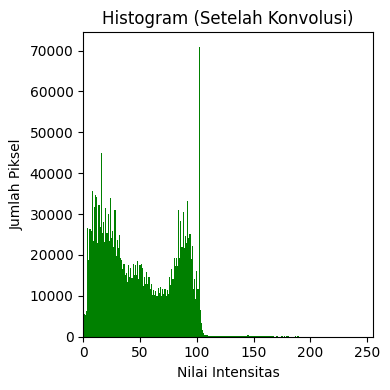

In [30]:
hist_conv = hitung_histogram(conv_clipped)

plt.figure(figsize=(4, 4))
plt.bar(range(256), hist_conv, color='green', width=1)
plt.title('Histogram (Setelah Konvolusi)')
plt.xlabel('Nilai Intensitas')
plt.ylabel('Jumlah Piksel')
plt.xlim([0, 255])
plt.tight_layout()
plt.show()

Kode tersebut digunakan untuk memvisualisasikan distribusi nilai intensitas piksel citra setelah melalui proses penajaman menggunakan fungsi hitung_histogram yang telah didefinisikan sebelumnya. Melalui grafik batang (bar chart), kita dapat melihat bagaimana operasi konvolusi dengan kernel sharpening memengaruhi kemunculan piksel, di mana biasanya intensitas akan lebih menyebar atau bergeser karena adanya penguatan kontras pada bagian tepi objek. Visualisasi ini membantu memverifikasi apakah hasil pemotongan nilai (clipping manual) pada rentang 0 hingga 255 telah berjalan dengan baik, yang ditunjukkan dengan tidak adanya nilai piksel yang berada di luar batas sumbu X pada grafik tersebut.

# KESIMPULAN

Secara keseluruhan, rangkaian kode tersebut mendemonstrasikan proses manipulasi citra digital yang komprehensif, mulai dari tahap pemrosesan awal hingga analisis frekuensi. Proses diawali dengan pembesaran citra (dilatasi) dan pemotongan spesifik untuk mengambil detail tertentu, yang kemudian disusun kembali menggunakan fungsi penggabungan horizontal dan vertikal guna membentuk gambar utuh yang baru. Setelah itu, kualitas visual ditingkatkan melalui normalisasi (peregangan kontras) untuk memastikan rentang warna berada pada spektrum optimal 0–255, yang dibuktikan dengan sebaran histogram yang lebih merata. Terakhir, citra diberikan filter penajaman melalui operasi konvolusi manual menggunakan kernel $4 \times 4$ dan teknik clipping manual untuk memperjelas tepi objek tanpa merusak data piksel. Kesimpulannya, alur ini berhasil mengubah citra yang awalnya redup atau kurang jelas menjadi citra yang lebih tajam, kontras, dan siap untuk dianalisis lebih lanjut secara detail.